In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from romlab import FOM, POD, OfflinePhase, OnlinePhase, Plot

files_train = ["snapshots.txt", "c-trace.txt", "mesh_coor2.txt", "parameters.txt"]
filenames_test  = ['snapshots_test.txt', 'c-trace_test.txt','mesh_coor2_test.txt', 'parameters_test.txt']

fom = FOM(
    data_folder=ROOT / "data/2d/lambda",
    filenames_train=files_train,
    filenames_test=filenames_test,
    mesh_file="mesh.vtk",
    model="extrudate_swell",
    param_cols=[0], seed = 42
)
fom.info()

extrudate_swell | 10 train, 100 test
dofs: velocity 4690, tr(c) 2345, mesh_coor2 2345


In [2]:
pod = POD(fom, centering = False, eps=1e-6)
pod.compute_basis()
pod.info()

velocity: 8/10 modes
c-trace: 8/10 modes
mesh_coor2: 7/10 modes


In [3]:
offline = OfflinePhase(fom, pod, x_scaler="minmax")
offline.train_rom()
offline.info()

velocity: 12.2**2 * RBF(length_scale=0.327)
c-trace: 384**2 * RBF(length_scale=0.344)
mesh_coor2: 12.1**2 * RBF(length_scale=0.388)


In [4]:
online = OnlinePhase(fom, pod, offline)
online.reconstruct_sol()
online.info()

velocity (relative error) = 1.83e-04
c-trace (relative error) = 2.88e-04
mesh_coor2 (relative error) = 3.58e-05


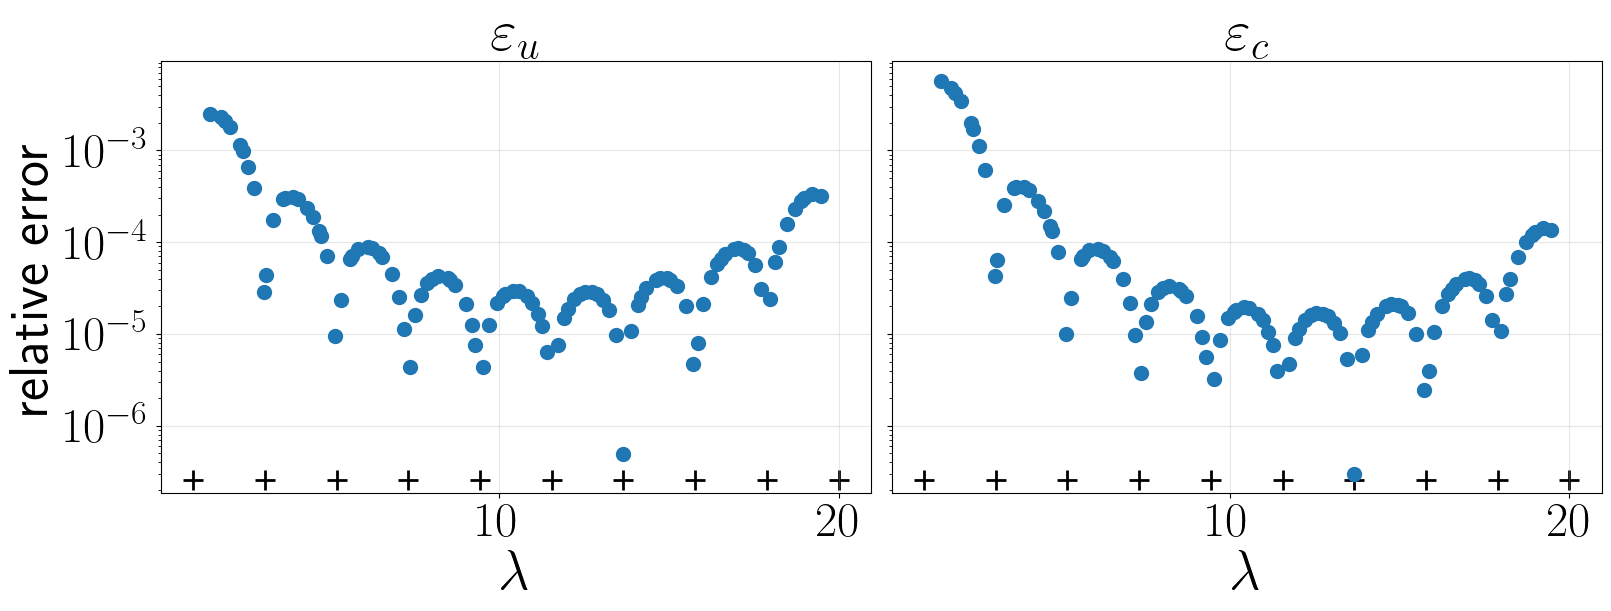

In [5]:
plot = Plot(fom, online)
plot.plot_relative_error()